### We are going to train the model on the Fashion Mnist dataset from kaggle 

In [2]:
import pandas as pd 
from sklearn.model_selection import train_test_split
import torch
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
from torch.optim import Adam
import matplotlib.pyplot as plt


In [3]:
torch.manual_seed(42)

In [4]:
import pandas as pd

file_path = r"C:\Users\Harshu\Downloads\archive (3)\fashion-mnist_train.csv"

df = pd.read_csv(file_path)
print(df.head())

   label  pixel1  pixel2  pixel3  pixel4  pixel5  pixel6  pixel7  pixel8  \
0      2       0       0       0       0       0       0       0       0   
1      9       0       0       0       0       0       0       0       0   
2      6       0       0       0       0       0       0       0       5   
3      0       0       0       0       1       2       0       0       0   
4      3       0       0       0       0       0       0       0       0   

   pixel9  ...  pixel775  pixel776  pixel777  pixel778  pixel779  pixel780  \
0       0  ...         0         0         0         0         0         0   
1       0  ...         0         0         0         0         0         0   
2       0  ...         0         0         0        30        43         0   
3       0  ...         3         0         0         0         0         1   
4       0  ...         0         0         0         0         0         0   

   pixel781  pixel782  pixel783  pixel784  
0         0         0         

In [5]:
df.head()

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,6,0,0,0,0,0,0,0,5,0,...,0,0,0,30,43,0,0,0,0,0
3,0,0,0,0,1,2,0,0,0,0,...,3,0,0,0,0,1,0,0,0,0
4,3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


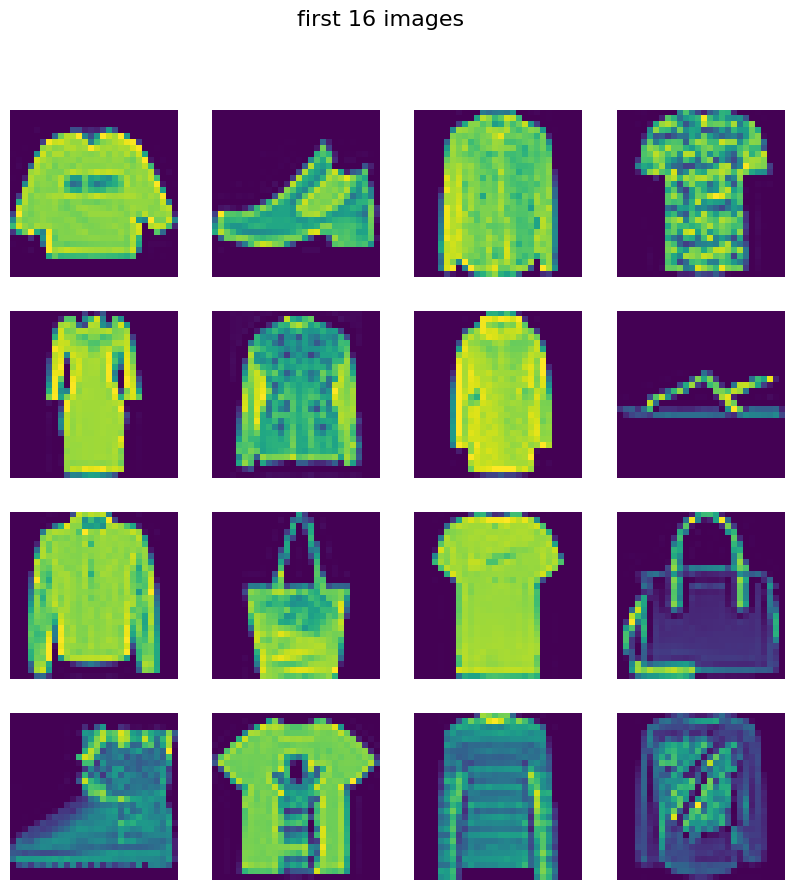

In [6]:
# create a 4*4 grid of images
fig, axes = plt.subplots(4, 4, figsize=(10, 10))
fig.suptitle("first 16 images ",fontsize= 16)

# Plot the first 16 images
for i , ax in enumerate(axes.flat):
    img = df.iloc[i, 1:].values.reshape(28, 28)  # reshape the pixel values to 28x28
    ax.imshow(img)
    ax.axis("off")  # hide axes

In [7]:
X = df.iloc[:, 1:].values
y = df.iloc[:, 0].values

In [8]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [9]:
X_train = X_train/255.0
X_test = X_test/255.0

In [10]:
class CustomDataset(Dataset):
    def __init__(self,features,labels):

        # Convert to pytorch tensors
        self.features = torch.tensor(features, dtype=torch.float32)
        self.labels = torch.tensor(labels, dtype=torch.long)

    def __len__(self):
        return len(self.features)

    def __getitem__(self, index):
        return self.features[index], self.labels[index] 
        

In [11]:
train_dataset = CustomDataset(X_train, y_train)

In [12]:
test_dataset = CustomDataset(X_test, y_test)

In [13]:
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

In [14]:
len(train_loader), len(test_loader)

(1500, 375)

In [15]:
# Define NN class
class MyNN(nn.Module):
    def __init__(self,num_features):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(num_features, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 10)
        )

    def forward(self,x):
        return self.model(x)
        

In [16]:
import torch.optim as optim
# Set learning rate and epochs
epochs = 100
learning_rate = 0.1

# Create an instance of the model
model = MyNN(X_train.shape[1])

# Define loss function and optimizer
criterion = nn.CrossEntropyLoss()

# Create an instance of the optimizer
optimizer = optim.SGD(model.parameters(), lr=learning_rate)

In [17]:
# training loop

for epoch in range(epochs):
    total_epoch_loss = 0

    for batch_features, batch_labels in train_loader:
        # Forward pass
        outputs = model(batch_features)
        loss = criterion(outputs, batch_labels)

        # Backward pass and optimization
        optimizer.zero_grad()
        loss.backward()

        # Update the model parameters
        optimizer.step()

        total_epoch_loss += loss.item()
    avg_loss = total_epoch_loss/len(train_loader)
    print(f"Epoch [{epoch+1}], Loss: {avg_loss}")

Epoch [1], Loss: 0.6351939923365911
Epoch [2], Loss: 0.42959494251509506
Epoch [3], Loss: 0.3859089352414012
Epoch [4], Loss: 0.35877482006450495
Epoch [5], Loss: 0.3369728716611862
Epoch [6], Loss: 0.32327799827357134
Epoch [7], Loss: 0.30831469855457544
Epoch [8], Loss: 0.29573114091406266
Epoch [9], Loss: 0.28465540171414616
Epoch [10], Loss: 0.2750463840464751
Epoch [11], Loss: 0.2685702230309447
Epoch [12], Loss: 0.25804841906825704
Epoch [13], Loss: 0.2506637729381522
Epoch [14], Loss: 0.2447239488090078
Epoch [15], Loss: 0.23892714732637008
Epoch [16], Loss: 0.23287287663544218
Epoch [17], Loss: 0.22483432456975183
Epoch [18], Loss: 0.21969401576245826
Epoch [19], Loss: 0.21704668447126946
Epoch [20], Loss: 0.21001548357990882
Epoch [21], Loss: 0.2080090798002978
Epoch [22], Loss: 0.20273179351352155
Epoch [23], Loss: 0.19483735175182423
Epoch [24], Loss: 0.19143487278558313
Epoch [25], Loss: 0.18705122634520133
Epoch [26], Loss: 0.1841448433206727
Epoch [27], Loss: 0.1839323067

In [18]:
# set model to evaluation mode
model.eval()


MyNN(
  (model): Sequential(
    (0): Linear(in_features=784, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=10, bias=True)
  )
)

In [20]:
# evaluate the model on the test set
total = 0
correct = 0

with torch.no_grad():
    for batch_features, batch_labels in train_loader:
        outputs = model(batch_features)
        _, predicted = torch.max(outputs, 1)
        total += batch_labels.size(0)
        correct += (predicted == batch_labels).sum().item()
print(f"Training Accuracy: {correct/total:.4f}")    

Training Accuracy: 0.9761


In [21]:
# evaluate the model on the test set
total = 0
correct = 0

with torch.no_grad():
    for batch_features, batch_labels in test_loader:
        outputs = model(batch_features)
        _, predicted = torch.max(outputs, 1)
        total += batch_labels.size(0)
        correct += (predicted == batch_labels).sum().item()
print(f"Test Accuracy: {correct/total:.4f}")    

Test Accuracy: 0.8832
